In [42]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [43]:
items = pd.read_csv("../../data/raw/items.csv", sep="|")
processedTrain = pd.read_csv("../../data/processed/processed_joined_dataset.csv", sep="|")

In [44]:
items.shape

(22035, 11)

In [45]:
items.describe()

,pid,manufacturer,genericProduct,salesIndex,category,rrp
count,22035.000000,22035.000000,22035.000000,22035.000000,17408.000000,22035.000000
mean,11018.000000,222.488042,0.033674,48.367461,113.933996,17.861648
std,6361.100927,223.103100,0.180392,6.166422,93.823387,19.823213
min,1.000000,1.000000,0.000000,40.000000,1.000000,0.070000
25%,5509.500000,60.000000,0.000000,40.000000,35.000000,7.260000
50%,11018.000000,156.000000,0.000000,53.000000,90.000000,12.080000
75%,16526.500000,311.000000,0.000000,53.000000,169.000000,21.270000
max,22035.000000,1067.000000,1.000000,53.000000,409.000000,404.970000


In [46]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 22035 entries, 0 to 22034
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pid             22035 non-null  int64  
 1   manufacturer    22035 non-null  int64  
 2   group           22035 non-null  str    
 3   content         22035 non-null  str    
 4   unit            22035 non-null  str    
 5   pharmForm       19708 non-null  str    
 6   genericProduct  22035 non-null  int64  
 7   salesIndex      22035 non-null  int64  
 8   category        17408 non-null  float64
 9   campaignIndex   1338 non-null   str    
 10  rrp             22035 non-null  float64
dtypes: float64(2), int64(4), str(5)
memory usage: 1.8 MB


In [47]:
items.head()

,pid,manufacturer,group,content,unit,pharmForm,genericProduct,salesIndex,category,campaignIndex,rrp
0,1,1,2FOI,80,ST,TAB,0,40,NaN,NaN,10.89
1,2,1,2FOI,80,ST,Tab,0,40,NaN,NaN,10.89
2,3,1,2FOI,10,G,GLO,0,40,NaN,NaN,16.45
3,4,1,2FOI,80,ST,TAB,0,40,NaN,NaN,10.89
4,5,2,10OJ03JS,8,ST,PUL,0,40,1.0,NaN,22.53


In [48]:
train = pd.read_csv("../../data/raw/train.csv", sep="|")

In [49]:
train.head()

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,revenue
0,1,1,6570,0,2,14.60,1,0,0,16.89,0.00
1,2,1,14922,1,1,8.57,0,1,0,8.75,0.00
2,3,1,16382,0,1,14.77,0,1,0,16.06,0.00
3,4,1,1145,1,1,6.59,0,0,1,6.55,6.55
4,5,1,3394,0,1,4.39,0,0,1,4.14,4.14


In [50]:
train.shape

(2756003, 11)

In [51]:
train.describe()

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,revenue
count,2.756003e+06,2.756003e+06,2.756003e+06,2.756003e+06,2.756003e+06,2.655316e+06,2.756003e+06,2.756003e+06,2.756003e+06,2.756003e+06,2.756003e+06
mean,1.378002e+06,4.992118e+01,1.044790e+04,3.177888e-01,1.111035e+00,1.277288e+01,5.743198e-01,1.698423e-01,2.558379e-01,1.385008e+01,3.750979e+00
std,7.955897e+05,2.529451e+01,6.456013e+03,4.656170e-01,3.921785e-01,1.275295e+01,4.944458e-01,3.754943e-01,4.363312e-01,1.362307e+01,1.023919e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-02,0.000000e+00
25%,6.890015e+05,3.100000e+01,4.313000e+03,0.000000e+00,1.000000e+00,5.480000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00
50%,1.378002e+06,5.000000e+01,1.007700e+04,0.000000e+00,1.000000e+00,8.990000e+00,1.000000e+00,0.000000e+00,0.000000e+00,9.850000e+00,0.000000e+00
75%,2.067002e+06,7.100000e+01,1.614400e+04,1.000000e+00,1.000000e+00,1.506000e+01,1.000000e+00,0.000000e+00,1.000000e+00,1.645000e+01,1.930000e+00
max,2.756003e+06,9.200000e+01,2.203500e+04,1.000000e+00,4.000000e+00,2.645900e+02,1.000000e+00,1.000000e+00,1.000000e+00,3.788400e+02,8.877000e+02


In [52]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756003 entries, 0 to 2756002
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   lineID           int64  
 1   day              int64  
 2   pid              int64  
 3   adFlag           int64  
 4   availability     int64  
 5   competitorPrice  float64
 6   click            int64  
 7   basket           int64  
 8   order            int64  
 9   price            float64
 10  revenue          float64
dtypes: float64(3), int64(8)
memory usage: 231.3 MB


In [53]:
#missing values
train.isna().sum()

lineID                  0
day                     0
pid                     0
adFlag                  0
availability            0
competitorPrice    100687
click                   0
basket                  0
order                   0
price                   0
revenue                 0
dtype: int64

In [54]:
#only click, basket, order
train[['click', 'basket', 'order']].sum()

click     1582827
basket     468086
order      705090
dtype: int64

In [55]:
#number of unique products
train['pid'].nunique()

21928

<Axes: >

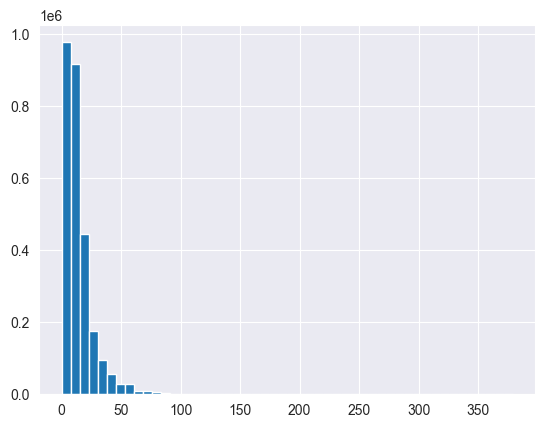

In [56]:
#viualization of price in absolute
train['price'].hist(bins=50)

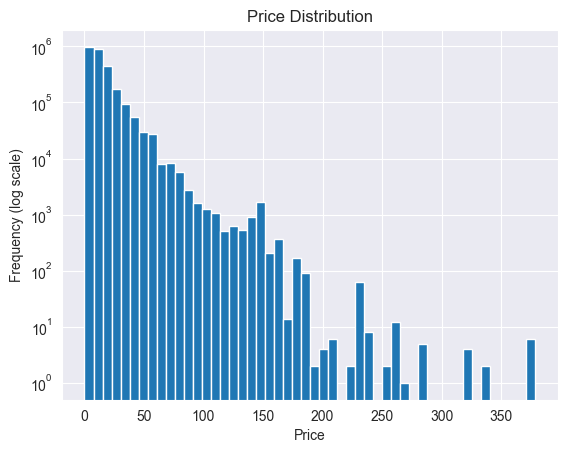

In [57]:
#visualization of price in relative Log
train['price'].hist(bins=50)
plt.yscale('log')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency (log scale)')
plt.grid(True)
plt.show()

#table shows that most items have a price between
#Price range	Frequency	Meaning
#0–20	extremely high	most products
#20–50	high	common
#50–100	moderate	less frequent
#100–200	rare	expensive
#200–400	very rare	outliers

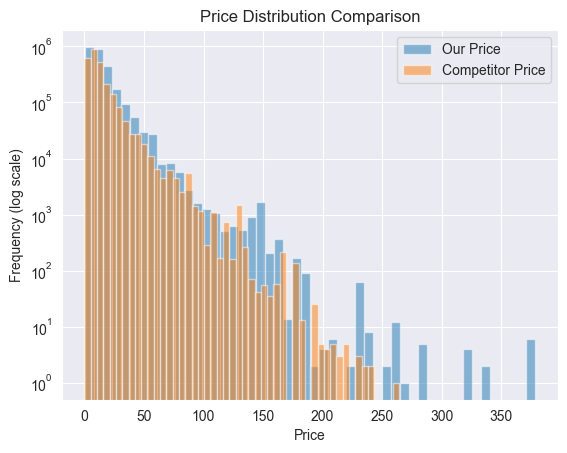

In [58]:
#in relation to the competitor
plt.hist(train['price'], bins=50, alpha=0.5, label='Our Price')
plt.hist(train['competitorPrice'], bins=50, alpha=0.5, label='Competitor Price')

plt.yscale('log')
plt.title('Price Distribution Comparison')
plt.xlabel('Price')
plt.ylabel('Frequency (log scale)')
plt.legend()
plt.grid(True)

plt.show()

In [59]:
#Data Cleaning
#competitor price has 100687 missing values
#trying to solve with imputation
#create 50 bin with our price and price of competitor
#compare them

# 1) Create equal-width bins on price
train['price_bin'] = pd.cut(train['price'], bins=50, include_lowest=True)

# 2) Build bin statistics from rows where competitorPrice is available
bin_stats = (
    train[train['competitorPrice'].notna()]
    .groupby('price_bin', observed=True)
    .agg(
        avg_price=('price', 'mean'),
        avg_competitor=('competitorPrice', 'mean'),
        count=('competitorPrice', 'count')
    )
)

# 3) Calculate percentage difference per bin
bin_stats['pct_diff'] = (
    (bin_stats['avg_competitor'] - bin_stats['avg_price'])
    / bin_stats['avg_price']
) * 100

bin_stats.head(50)

,avg_price,avg_competitor,count,pct_diff
price_bin,,,,
"(-0.36, 7.596]",4.642589,4.570048,948273,-1.562524
"(7.596, 15.173]",10.577319,9.766895,888819,-7.661902
"(15.173, 22.749]",17.792070,16.177233,430018,-9.076162
"(22.749, 30.326]",26.378587,24.402058,164711,-7.492930
"(30.326, 37.902]",33.381021,31.562449,90162,-5.447922
"(37.902, 45.478]",40.805105,44.844527,52972,9.899308
"(45.478, 53.055]",48.835514,44.383411,25735,-9.116527
"(53.055, 60.631]",56.431362,50.661446,25248,-10.224663
"(60.631, 68.208]",64.541170,57.542344,6924,-10.843971


In [60]:
bin_stats['count']

price_bin
(-0.36, 7.596]        948273
(7.596, 15.173]       888819
(15.173, 22.749]      430018
(22.749, 30.326]      164711
(30.326, 37.902]       90162
(37.902, 45.478]       52972
(45.478, 53.055]       25735
(53.055, 60.631]       25248
(60.631, 68.208]        6924
(68.208, 75.784]        7558
(75.784, 83.36]         4605
(83.36, 90.937]         2240
(90.937, 98.513]        1455
(98.513, 106.09]        1192
(106.09, 113.666]        862
(113.666, 121.242]       448
(121.242, 128.819]       563
(128.819, 136.395]       503
(136.395, 143.972]       726
(143.972, 151.548]      1613
(151.548, 159.124]       103
(159.124, 166.701]       282
(166.701, 174.277]        13
(174.277, 181.854]       170
(181.854, 189.43]         90
(189.43, 197.006]          1
(197.006, 204.583]         1
(204.583, 212.159]         2
(227.312, 234.888]         6
(234.888, 242.465]         2
(257.618, 265.194]        10
(265.194, 272.77]          1
(280.347, 287.923]         5
(318.229, 325.805]         3
Name

In [61]:
#now i want to insert the missing competitor prices

missing_rows = train[train['competitorPrice'].isna()]
print(missing_rows)


          lineID  day    pid  adFlag  availability  competitorPrice  click  \
14            15    1  21983       0             1              NaN      0   
63            64    1  19317       0             1              NaN      0   
64            65    1   9482       0             1              NaN      1   
82            83    1  19949       0             2              NaN      1   
99           100    1   4232       0             1              NaN      0   
...          ...  ...    ...     ...           ...              ...    ...   
2755875  2755876   92   2949       0             3              NaN      0   
2755933  2755934   92  21746       1             1              NaN      0   
2755951  2755952   92  21638       0             2              NaN      1   
2755975  2755976   92  20824       0             1              NaN      1   
2755986  2755987   92   4957       0             1              NaN      1   

         basket  order  price  revenue         price_bin  
14  

In [62]:
# 4) Get only rows with missing competitorPrice
missing_prices = train[train['competitorPrice'].isna()].copy()

# 5) Bring pct_diff into the missing-values table
missing_prices = missing_prices.merge(
    bin_stats[['pct_diff']],
    left_on='price_bin',
    right_index=True,
    how='left'
)

# 6) Estimate competitorPrice using your formula
missing_prices['estimated_competitorPrice'] = (
    missing_prices['price']
    + (missing_prices['price'] / 100 * missing_prices['pct_diff'])
)

# 7) Keep only useful columns for testing
missing_prices = missing_prices[
    ['lineID', 'pid', 'day', 'price', 'price_bin', 'pct_diff', 'estimated_competitorPrice']
]

# show first rows
print(missing_prices.head())

    lineID    pid  day  price         price_bin   pct_diff  \
14      15  21983    1  54.95  (53.055, 60.631] -10.224663   
63      64  19317    1   3.82    (-0.36, 7.596]  -1.562524   
64      65   9482    1   3.34    (-0.36, 7.596]  -1.562524   
82      83  19949    1  14.19   (7.596, 15.173]  -7.661902   
99     100   4232    1   7.65   (7.596, 15.173]  -7.661902   

    estimated_competitorPrice  
14                  49.331548  
63                   3.760312  
64                   3.287812  
82                  13.102776  
99                   7.063864  


In [63]:
print(train)


          lineID  day    pid  adFlag  availability  competitorPrice  click  \
0              1    1   6570       0             2            14.60      1   
1              2    1  14922       1             1             8.57      0   
2              3    1  16382       0             1            14.77      0   
3              4    1   1145       1             1             6.59      0   
4              5    1   3394       0             1             4.39      0   
...          ...  ...    ...     ...           ...              ...    ...   
2755998  2755999   92  15767       0             1            22.41      1   
2755999  2756000   92   2087       0             1            36.87      1   
2756000  2756001   92   2944       0             1             4.71      1   
2756001  2756002   92   3853       1             1             6.59      0   
2756002  2756003   92   3854       1             1             8.78      1   

         basket  order  price  revenue         price_bin  
0   

In [64]:
processedTrain = pd.read_csv("../../data/processed/processed_joined_dataset.csv", sep="|")
print(processedTrain)

          lineID  day    pid  adFlag  availability  competitorPrice  click  \
0              1    1   6570       0             2            14.60      1   
1              2    1  14922       1             1             8.57      0   
2              3    1  16382       0             1            14.77      0   
3              4    1   1145       1             1             6.59      0   
4              5    1   3394       0             1             4.39      0   
...          ...  ...    ...     ...           ...              ...    ...   
2755789  2755999   92  15767       0             1            22.41      1   
2755790  2756000   92   2087       0             1            36.87      1   
2755791  2756001   92   2944       0             1             4.71      1   
2755792  2756002   92   3853       1             1             6.59      0   
2755793  2756003   92   3854       1             1             8.78      1   

         basket  order  price  ...  salesIndex  category    rrp

In [65]:
#checking for NA in missing_prices
print(missing_prices['estimated_competitorPrice'].isna().count())

100687


In [66]:
print(missing_prices.info())

<class 'pandas.DataFrame'>
Index: 100687 entries, 14 to 2755986
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   lineID                     100687 non-null  int64   
 1   pid                        100687 non-null  int64   
 2   day                        100687 non-null  int64   
 3   price                      100687 non-null  float64 
 4   price_bin                  100687 non-null  category
 5   pct_diff                   100675 non-null  float64 
 6   estimated_competitorPrice  100675 non-null  float64 
dtypes: category(1), float64(3), int64(3)
memory usage: 5.5 MB
None


Relation between addFlag, click, basket & order

In [67]:
#probabilites
action_rates = train.groupby("adFlag")[["click", "basket", "order"]].mean()
print(action_rates)

           click    basket     order
adFlag                              
0       0.634850  0.140317  0.224834
1       0.444378  0.233226  0.322396


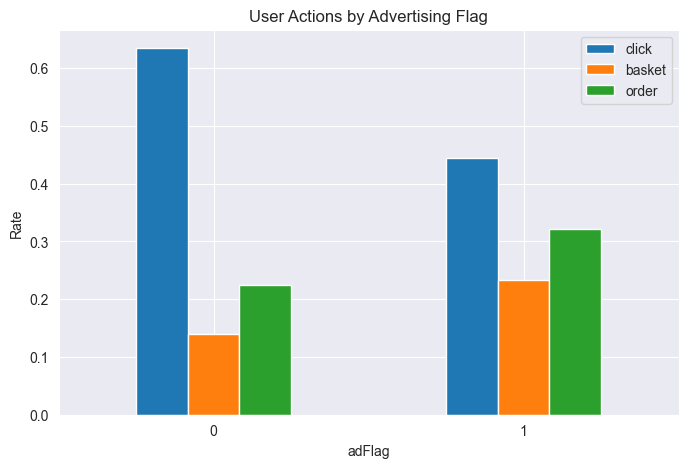

In [68]:
#visualization
action_rates.plot(kind="bar", figsize=(8,5))

plt.title("User Actions by Advertising Flag")
plt.ylabel("Rate")
plt.xlabel("adFlag")
plt.xticks(rotation=0)
plt.show()

Products with an active advertising flag show  higher basket and order rates compared to products without advertising.
Interestingly, the click rate is lower for advertised products.
This suggests that advertising may not primarily increase product visibility, but rather improves the conversion of already interested customers into purchases.

Now lets find out if products with basket and order rate are generally cheaper in each of the 50 bins

In [69]:
processedTrain.info()

<class 'pandas.DataFrame'>
RangeIndex: 2755794 entries, 0 to 2755793
Data columns (total 27 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   lineID                     int64  
 1   day                        int64  
 2   pid                        int64  
 3   adFlag                     int64  
 4   availability               int64  
 5   competitorPrice            float64
 6   click                      int64  
 7   basket                     int64  
 8   order                      int64  
 9   price                      float64
 10  revenue                    float64
 11  manufacturer               int64  
 12  group                      str    
 13  content                    int64  
 14  unit                       str    
 15  pharmForm                  str    
 16  genericProduct             int64  
 17  salesIndex                 int64  
 18  category                   float64
 19  rrp                        float64
 20  has_competito

In [70]:
funnel = processedTrain.groupby("adFlag")[["click", "basket", "order"]].sum()

# impressions = total rows
funnel["impression"] = train.groupby("adFlag").size()

funnel = funnel[["impression", "click", "basket", "order"]]

print(funnel)

        impression    click  basket   order
adFlag                                     
0          1880176  1193451  263808  422708
1           875827   389198  204266  282363


In [71]:
funnel_rates = funnel.copy()

funnel_rates["click_rate"] = funnel["click"] / funnel["impression"]
funnel_rates["basket_rate"] = funnel["basket"] / funnel["impression"]
funnel_rates["order_rate"] = funnel["order"] / funnel["impression"]

print(funnel_rates)

        impression    click  basket   order  click_rate  basket_rate  \
adFlag                                                                 
0          1880176  1193451  263808  422708    0.634755     0.140310   
1           875827   389198  204266  282363    0.444378     0.233226   

        order_rate  
adFlag              
0         0.224824  
1         0.322396  


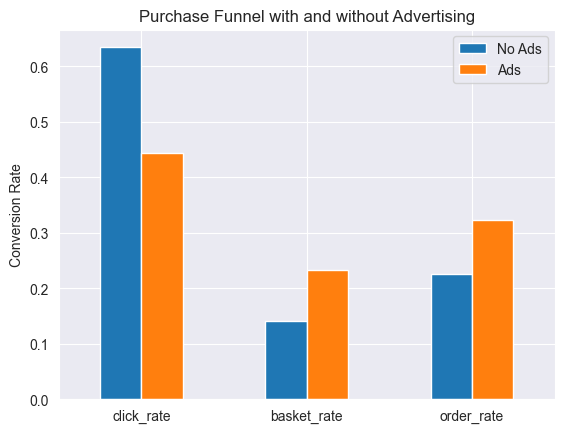

In [72]:
import matplotlib.pyplot as plt

funnel_rates[["click_rate", "basket_rate", "order_rate"]].T.plot(kind="bar")

plt.ylabel("Conversion Rate")
plt.title("Purchase Funnel with and without Advertising")
plt.xticks(rotation=0)
plt.legend(["No Ads", "Ads"])
plt.show()

In [73]:
processedTrain["price_bin"] = pd.cut(processedTrain["price"], bins =50, include_lowest=True)

print("price distribution")
print(processedTrain["price_bin"].value_counts())

price distribution
price_bin
(-0.36, 7.596]        977833
(7.596, 15.173]       916013
(15.173, 22.749]      446358
(22.749, 30.326]      174563
(30.326, 37.902]       94278
(37.902, 45.478]       56144
(45.478, 53.055]       29157
(53.055, 60.631]       27637
(68.208, 75.784]        8390
(60.631, 68.208]        7864
(75.784, 83.36]         5730
(83.36, 90.937]         2700
(143.972, 151.548]      1663
(90.937, 98.513]        1599
(98.513, 106.09]        1284
(106.09, 113.666]       1049
(136.395, 143.972]       890
(121.242, 128.819]       619
(128.819, 136.395]       529
(113.666, 121.242]       518
(159.124, 166.701]       373
(151.548, 159.124]       210
(174.277, 181.854]       171
(181.854, 189.43]         90
(227.312, 234.888]        64
(166.701, 174.277]        14
(257.618, 265.194]        12
(234.888, 242.465]         8
(204.583, 212.159]         6
(371.264, 378.84]          6
(280.347, 287.923]         5
(197.006, 204.583]         4
(318.229, 325.805]         4
(189.43, 197.0

In [74]:
count_pid5022 = train[train['pid'] == 5022]
print(count_pid5022)
count_pid5022.info()



          lineID  day   pid  adFlag  availability  competitorPrice  click  \
22476      22477    2  5022       0             1            24.81      1   
70689      70690    4  5022       0             1            24.81      1   
81615      81616    4  5022       0             1            24.81      1   
114778    114779    6  5022       0             1            25.29      1   
121051    121052    6  5022       0             1            25.29      1   
...          ...  ...   ...     ...           ...              ...    ...   
2599553  2599554   88  5022       0             1            25.29      1   
2638181  2638182   89  5022       0             1            25.29      1   
2701011  2701012   91  5022       0             1            24.81      1   
2716269  2716270   91  5022       0             1            24.81      1   
2751111  2751112   92  5022       0             1            24.81      1   

         basket  order  price  revenue         price_bin  
22476         0 

In [75]:
count_pid5799 = train[train['pid'] == 5799]
print(count_pid5799)
count_pid5799.info()

          lineID  day   pid  adFlag  availability  competitorPrice  click  \
69644      69645    4  5799       0             1             9.33      0   
87197      87198    5  5799       0             1             9.33      0   
87568      87569    5  5799       0             1             9.33      0   
175020    175021    9  5799       0             1             9.34      0   
197244    197245   10  5799       0             2             9.34      0   
...          ...  ...   ...     ...           ...              ...    ...   
2604005  2604006   88  5799       0             1             9.33      1   
2636632  2636633   89  5799       0             1             9.33      1   
2655398  2655399   90  5799       0             1             9.33      1   
2655630  2655631   90  5799       0             1             9.33      1   
2743758  2743759   92  5799       0             1            11.26      1   

         basket  order  price  revenue        price_bin  
69644         0  

In [76]:
price_equals_0 = processedTrain[processedTrain['competitorPrice'].eq(0)]
price_equals_0.info()
price_equals_0.head()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   lineID                     0 non-null      int64   
 1   day                        0 non-null      int64   
 2   pid                        0 non-null      int64   
 3   adFlag                     0 non-null      int64   
 4   availability               0 non-null      int64   
 5   competitorPrice            0 non-null      float64 
 6   click                      0 non-null      int64   
 7   basket                     0 non-null      int64   
 8   order                      0 non-null      int64   
 9   price                      0 non-null      float64 
 10  revenue                    0 non-null      float64 
 11  manufacturer               0 non-null      int64   
 12  group                      0 non-null      str     
 13  content                    0 non-null      int64   
 14  u

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,category,rrp,has_competitor,campaignIndex_A,campaignIndex_B,campaignIndex_C,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor,price_bin


In [77]:
price_equals_0_train = train[train['competitorPrice'].eq(0)]
price_equals_0_train.info()
price_equals_0_train.head()

<class 'pandas.DataFrame'>
Index: 976 entries, 20744 to 2739506
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   lineID           976 non-null    int64   
 1   day              976 non-null    int64   
 2   pid              976 non-null    int64   
 3   adFlag           976 non-null    int64   
 4   availability     976 non-null    int64   
 5   competitorPrice  976 non-null    float64 
 6   click            976 non-null    int64   
 7   basket           976 non-null    int64   
 8   order            976 non-null    int64   
 9   price            976 non-null    float64 
 10  revenue          976 non-null    float64 
 11  price_bin        976 non-null    category
dtypes: category(1), float64(3), int64(8)
memory usage: 97.3 KB


,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,revenue,price_bin
20744,20745,2,79,0,1,0.0,0,1,0,0.55,0.00,"(-0.36, 7.596]"
21255,21256,2,79,0,1,0.0,0,0,1,0.55,0.55,"(-0.36, 7.596]"
31090,31091,2,79,0,1,0.0,1,0,0,0.55,0.00,"(-0.36, 7.596]"
34646,34647,2,79,0,1,0.0,1,0,0,0.55,0.00,"(-0.36, 7.596]"
42233,42234,3,79,0,1,0.0,0,0,1,0.55,0.55,"(-0.36, 7.596]"


In [78]:
price_equals_na = processedTrain[processedTrain['competitorPrice'].isna()]
price_equals_na.info()
price_equals_na.head()

<class 'pandas.DataFrame'>
Index: 101663 entries, 14 to 2755777
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   lineID                     101663 non-null  int64   
 1   day                        101663 non-null  int64   
 2   pid                        101663 non-null  int64   
 3   adFlag                     101663 non-null  int64   
 4   availability               101663 non-null  int64   
 5   competitorPrice            0 non-null       float64 
 6   click                      101663 non-null  int64   
 7   basket                     101663 non-null  int64   
 8   order                      101663 non-null  int64   
 9   price                      101663 non-null  float64 
 10  revenue                    101663 non-null  float64 
 11  manufacturer               101663 non-null  int64   
 12  group                      101663 non-null  str     
 13  content                    1

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,category,rrp,has_competitor,campaignIndex_A,campaignIndex_B,campaignIndex_C,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor,price_bin
14,15,1,21983,0,1,NaN,0,0,1,54.95,...,123.0,65.95,0,0,0,0,NaN,NaN,NaN,"(53.055, 60.631]"
63,64,1,19317,0,1,NaN,0,1,0,3.82,...,20.0,4.12,0,0,0,0,NaN,NaN,NaN,"(-0.36, 7.596]"
64,65,1,9482,0,1,NaN,1,0,0,3.34,...,202.0,3.62,0,0,0,0,NaN,NaN,NaN,"(-0.36, 7.596]"
82,83,1,19949,0,2,NaN,1,0,0,14.19,...,9.0,15.35,0,0,0,0,NaN,NaN,NaN,"(7.596, 15.173]"
99,100,1,4232,0,1,NaN,0,1,0,7.65,...,25.0,7.65,0,0,1,0,NaN,NaN,NaN,"(7.596, 15.173]"


In [79]:
line_23909 = processedTrain[processedTrain['lineID'] == 23909]
print(line_23909)

       lineID  day   pid  adFlag  availability  competitorPrice  click  \
23907   23909    2  7680       1             1             5.38      0   

       basket  order  price  ...  category    rrp has_competitor  \
23907       1      0   5.45  ...      50.0  11.55              1   

       campaignIndex_A campaignIndex_B campaignIndex_C  price_diff_competitor  \
23907                0               0               0                   0.07   

       price_ratio_competitor  price_pct_diff_competitor       price_bin  
23907                   1.013                        1.3  (-0.36, 7.596]  

[1 rows x 28 columns]


In [80]:
print((processedTrain["competitorPrice"] == 0).sum())
print(processedTrain["competitorPrice"].isna().sum())

0
101663


In [81]:
unique_items = processedTrain(processedTrain["salesindex"].unique())
print(unique_items)

KeyError: 'salesindex'